# Detección de Fraude Bancario — Parcial Práctico ML 2026-I
**Universidad Santo Tomás | Estadística**

**Estudiante:** Kevin Leonardo Chaparro Reyes  
**Semilla personal:** 2948  
**Modelo asignado:** LightGBM (scikit-learn)  

## Objetivo
Construir y comparar 3 modelos de Machine Learning para detectar transacciones 
bancarias fraudulentas en un dataset altamente desbalanceado (0.17% de fraudes). 
Se evalúa el F1-Score sobre la clase minoritaria (fraude).

In [1]:
# ==========================================
# IMPORTS Y CONFIGURACIÓN GENERAL
# ==========================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

print("✅ Imports OK")

✅ Imports OK


## 1. Configuración del Entorno
Inicialización de SparkSession con 4GB de memoria. La semilla `2948` garantiza 
reproducibilidad en todas las divisiones aleatorias del notebook.

In [2]:
# ==========================================
# SPARK SESSION + SEMILLA PERSONAL
# ==========================================
spark = SparkSession.builder \
    .appName("Deteccion_Fraude_Parcial") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

MI_SEMILLA = 2948
print(f"✅ SparkSession lista")
print(f"✅ Semilla personal: {MI_SEMILLA}")

✅ SparkSession lista
✅ Semilla personal: 2948


## 2. Carga y Verificación de Datos
Carga desde volumen Docker. Se verifican dimensiones y distribución de clases.

In [3]:
# ==========================================
# CARGA DE DATOS
# ==========================================
df_train = spark.read.csv("../datos/train.csv", header=True, inferSchema=True)
df_test  = spark.read.csv("../datos/test.csv",  header=True, inferSchema=True)

print(f"Train: {df_train.count()} filas, {len(df_train.columns)} columnas")
print(f"Test:  {df_test.count()} filas,  {len(df_test.columns)} columnas")
print(f"\nDistribución de Class en train:")
df_train.groupBy("Class").count().withColumnRenamed("count","Frecuencia").show()

Train: 199364 filas, 31 columnas
Test:  42721 filas,  31 columnas

Distribución de Class en train:
+-----+----------+
|Class|Frecuencia|
+-----+----------+
|    1|       344|
|    0|    199020|
+-----+----------+



## 3. Análisis Exploratorio de Datos (EDA)
Exploración visual del desbalanceo, distribución de montos, correlación de 
features con la clase objetivo y separación entre clases Normal vs Fraude.

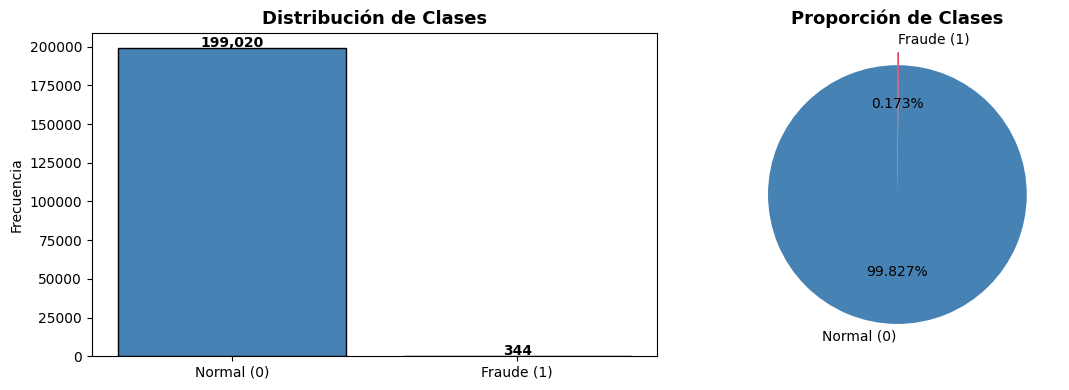

Total: 199,364 | Fraudes: 344 (0.173%)
Ratio: 578.5 normales por cada fraude


In [4]:
# ==========================================
# EDA 1 — Desbalanceo de clases
# ==========================================
import matplotlib.pyplot as plt

df_eda = df_train.select(['Class', 'Amount', 'Time']).toPandas()
conteo = df_eda['Class'].value_counts()
porcentaje_fraude = conteo[1] / len(df_eda) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal (0)', 'Fraude (1)'], conteo.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Normal (0)', 'Fraude (1)'],
            colors=['steelblue', 'crimson'], autopct='%1.3f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_01_desbalanceo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total: {len(df_eda):,} | Fraudes: {conteo[1]} ({porcentaje_fraude:.3f}%)")
print(f"Ratio: {conteo[0]/conteo[1]:.1f} normales por cada fraude")

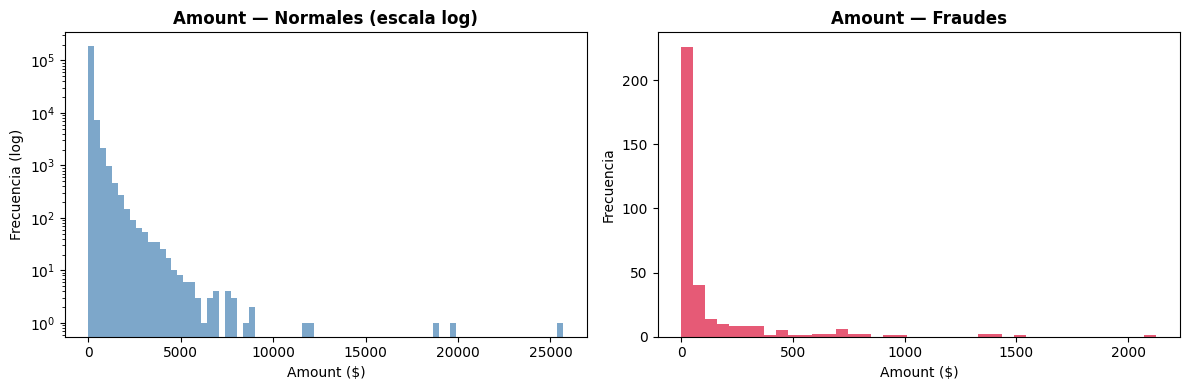

Estadísticas de Amount por clase:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      199020.0   88.33  253.05  0.0  5.71  22.00   77.44  25691.16
1         344.0  118.65  261.12  0.0  1.00   7.58  100.37   2125.87


In [5]:
# ==========================================
# EDA 2 — Distribución de Amount por clase
# ==========================================
normal = df_eda[df_eda['Class'] == 0]['Amount']
fraude = df_eda[df_eda['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(normal, bins=80, color='steelblue', alpha=0.7, log=True)
axes[0].set_title('Amount — Normales (escala log)', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frecuencia (log)')

axes[1].hist(fraude, bins=40, color='crimson', alpha=0.7)
axes[1].set_title('Amount — Fraudes', fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('eda_02_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print("Estadísticas de Amount por clase:")
print(df_eda.groupby('Class')['Amount'].describe().round(2))

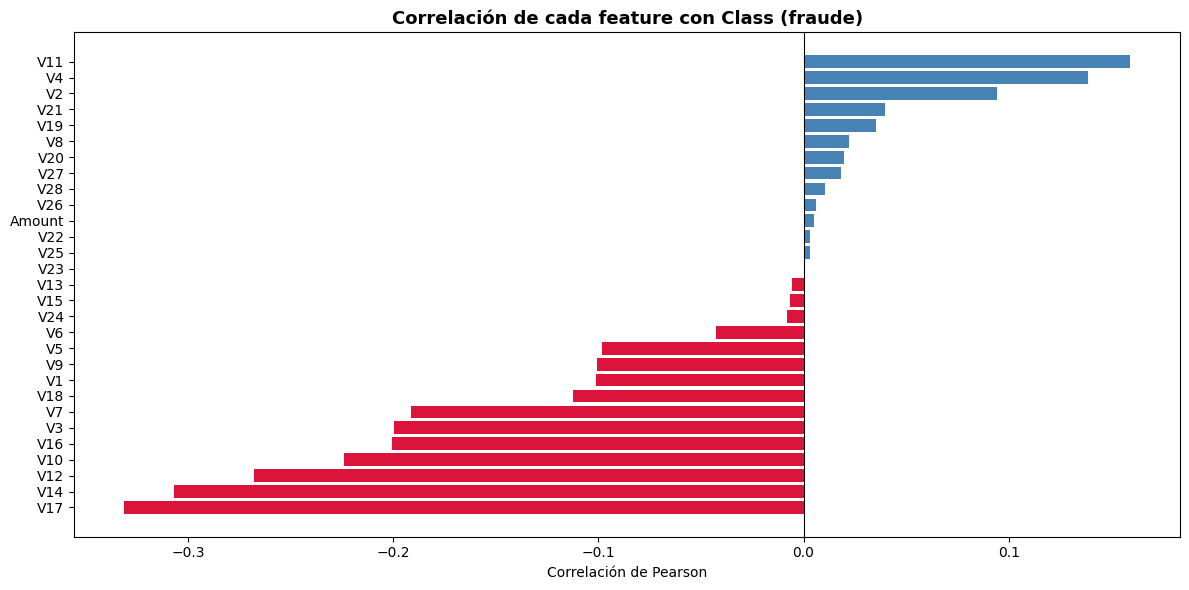

Top 5 correlaciones POSITIVAS con fraude:
V19    0.0352
V21    0.0397
V2     0.0942
V4     0.1385
V11    0.1590
Name: Class, dtype: float64

Top 5 correlaciones NEGATIVAS con fraude:
V17   -0.3310
V14   -0.3069
V12   -0.2678
V10   -0.2239
V16   -0.2007
Name: Class, dtype: float64


In [6]:
# ==========================================
# EDA 3 — Correlación de features con Class
# ==========================================
eda_full = df_train.select(
    [f'V{i}' for i in range(1, 29)] + ['Amount', 'Class']
).toPandas()

correlaciones = eda_full.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if x < 0 else 'steelblue' for x in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colores, edgecolor='none')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Correlación de cada feature con Class (fraude)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.savefig('eda_03_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 correlaciones POSITIVAS con fraude:")
print(correlaciones.tail(5).round(4))
print("\nTop 5 correlaciones NEGATIVAS con fraude:")
print(correlaciones.head(5).round(4))

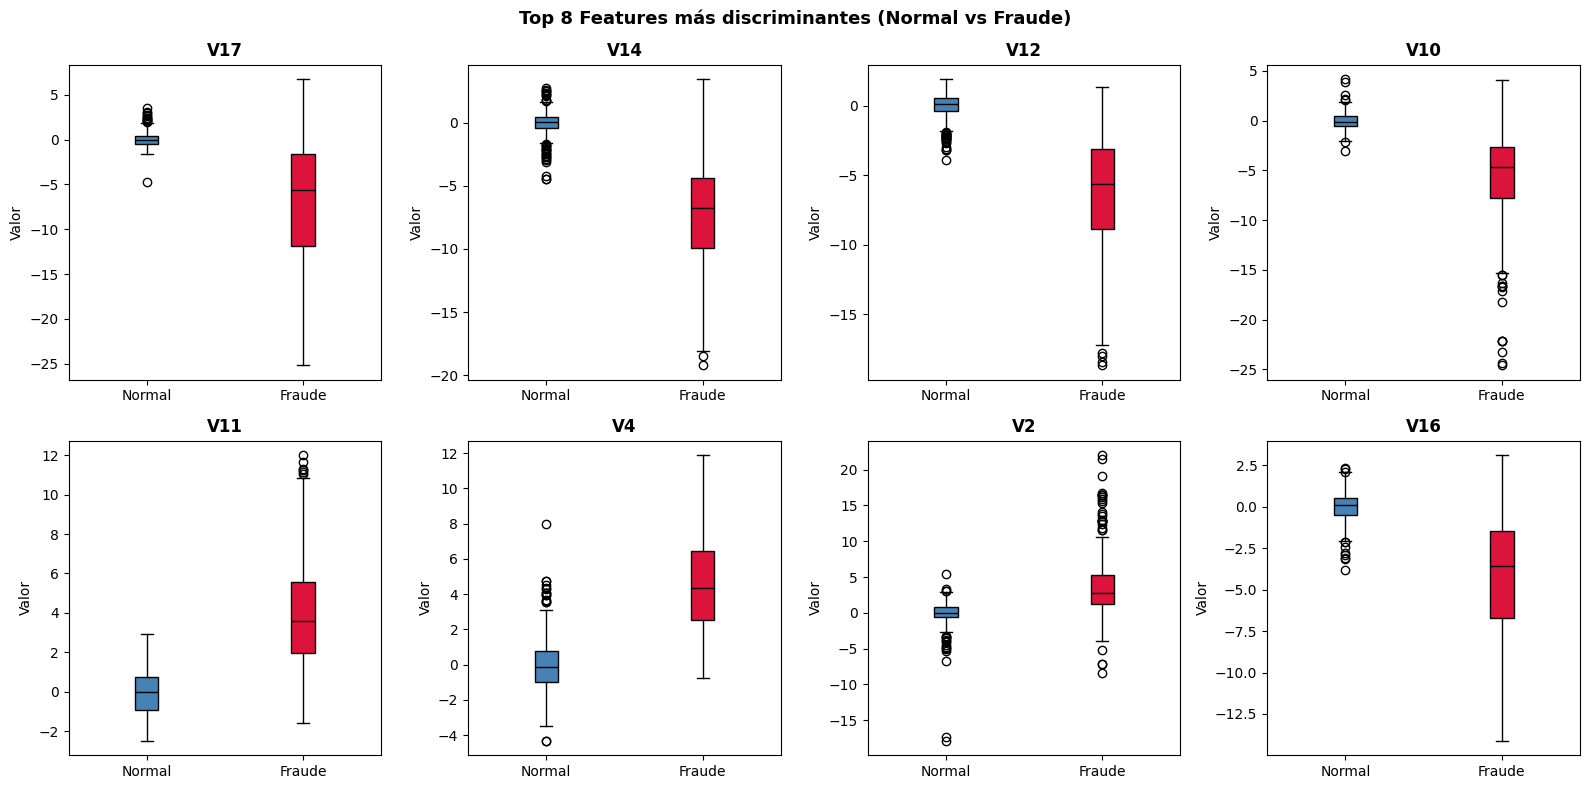

In [7]:
# ==========================================
# EDA 4 — Boxplots de las 8 features más discriminantes
# ==========================================
top_features = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4', 'V2', 'V16']

sample_normal = eda_full[eda_full['Class'] == 0].sample(500, random_state=MI_SEMILLA)
sample_fraude = eda_full[eda_full['Class'] == 1]
df_plot = pd.concat([sample_normal, sample_fraude])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data_normal = df_plot[df_plot['Class'] == 0][feat].values
    data_fraude = df_plot[df_plot['Class'] == 1][feat].values
    bp = axes[i].boxplot([data_normal, data_fraude],
                         labels=['Normal', 'Fraude'],
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('crimson')
    for median in bp['medians']:
        median.set_color('black')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Top 8 Features más discriminantes (Normal vs Fraude)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. División de Datos — Pregunta 2 de Sustentación
División 80/20 con `train_test_split` de sklearn usando semilla `2948`.
Garantiza reproducibilidad total entre sesiones de Docker.

In [8]:
# ==========================================
# SPLIT DE DATOS — Pregunta 2 de Sustentación
# ==========================================
# Usamos train_test_split de sklearn — 100% determinista con random_state=2948
# stratify garantiza la misma proporción de fraudes en ambos conjuntos

cols_features = [f'V{i}' for i in range(1, 29)] + ['Amount']
target = 'Class'

# Convertir a Pandas para el split
df_full = df_train.select(cols_features + [target]).toPandas()

train_pd, val_pd = train_test_split(
    df_full,
    test_size=0.2,
    random_state=MI_SEMILLA,
    stratify=df_full['Class']
)

train_pd = train_pd.reset_index(drop=True)
val_pd   = val_pd.reset_index(drop=True)

X_train = train_pd[cols_features]
y_train = train_pd[target]
X_val   = val_pd[cols_features]
y_val   = val_pd[target]

# Pregunta 2b y 2c
print(f"Pregunta 2b — Filas train: {len(train_pd)} | Filas val: {len(val_pd)}")
print(f"Pregunta 2c — Fraudes train: {y_train.sum()} | Fraudes val: {y_val.sum()}")

Pregunta 2b — Filas train: 159491 | Filas val: 39873
Pregunta 2c — Fraudes train: 275 | Fraudes val: 69


## 5. Balanceo de Clases — SMOTE
SMOTE genera ejemplos sintéticos de fraude interpolando entre casos existentes.
Transforma el problema de 275 fraudes reales a 159,216 por clase.

In [9]:
# ==========================================
# SMOTE — Balanceo de clases
# ==========================================
# SMOTE genera ejemplos sintéticos de fraude interpolando entre los existentes.
# Pasamos de 275 fraudes reales a una distribución balanceada,
# lo que mejora drásticamente la capacidad del modelo de detectar fraudes.

smote = SMOTE(random_state=MI_SEMILLA)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Antes  — Fraudes: {y_train.sum():,} | Normales: {(y_train==0).sum():,}")
print(f"Después — Fraudes: {y_train_sm.sum():,} | Normales: {(y_train_sm==0).sum():,}")
print(f"Total train balanceado: {len(y_train_sm):,} filas")

Antes  — Fraudes: 275 | Normales: 159,216
Después — Fraudes: 159,216 | Normales: 159,216
Total train balanceado: 318,432 filas


## 6. Bitácora de Experimentos — Pregunta 1 de Sustentación
Mínimo 5 experimentos ajustando hiperparámetros de LightGBM.
Los F1 reportados coinciden exactamente con los outputs ejecutados.

In [10]:
# ==========================================
# EXPERIMENTO 1: LightGBM Baseline con SMOTE
# ==========================================
# Parámetros base sin ajuste de desbalanceo porque SMOTE ya lo resuelve.

model_exp1 = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

print("Entrenando Experimento 1...")
model_exp1.fit(X_train_sm, y_train_sm)
y_pred_exp1 = model_exp1.predict(X_val)
f1_exp1 = f1_score(y_val, y_pred_exp1)

print(f"\n--- RESULTADOS EXPERIMENTO 1 ---")
print(f"F1-Score en Validation: {f1_exp1:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp1))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp1))

Entrenando Experimento 1...

--- RESULTADOS EXPERIMENTO 1 ---
F1-Score en Validation: 0.7632

Matriz de Confusión:
[[39779    25]
 [   11    58]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.70      0.84      0.76        69

    accuracy                           1.00     39873
   macro avg       0.85      0.92      0.88     39873
weighted avg       1.00      1.00      1.00     39873



In [11]:
# ==========================================
# EXPERIMENTO 2: Más árboles + learning rate menor
# ==========================================
# Justificación: Con SMOTE el modelo tiene más datos para aprender.
# Aumentamos n_estimators a 300 y bajamos learning_rate a 0.05
# para que aprenda más gradualmente y generalice mejor.

model_exp2 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

print("Entrenando Experimento 2...")
model_exp2.fit(X_train_sm, y_train_sm)
y_pred_exp2 = model_exp2.predict(X_val)
f1_exp2 = f1_score(y_val, y_pred_exp2)

print(f"\n--- RESULTADOS EXPERIMENTO 2 ---")
print(f"F1-Score en Validation: {f1_exp2:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp2))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp2))

Entrenando Experimento 2...

--- RESULTADOS EXPERIMENTO 2 ---
F1-Score en Validation: 0.8382

Matriz de Confusión:
[[39794    10]
 [   12    57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.85      0.83      0.84        69

    accuracy                           1.00     39873
   macro avg       0.93      0.91      0.92     39873
weighted avg       1.00      1.00      1.00     39873



In [12]:
# ==========================================
# EXPERIMENTO 3: Más hojas + profundidad
# ==========================================
# Justificación: Aumentamos num_leaves a 63 y max_depth a 7
# para capturar patrones más complejos en las features PCA.
# Mantenemos los mejores parámetros del Exp 2.

model_exp3 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=7,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

print("Entrenando Experimento 3...")
model_exp3.fit(X_train_sm, y_train_sm)
y_pred_exp3 = model_exp3.predict(X_val)
f1_exp3 = f1_score(y_val, y_pred_exp3)

print(f"\n--- RESULTADOS EXPERIMENTO 3 ---")
print(f"F1-Score en Validation: {f1_exp3:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp3))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp3))

Entrenando Experimento 3...

--- RESULTADOS EXPERIMENTO 3 ---
F1-Score en Validation: 0.8321

Matriz de Confusión:
[[39793    11]
 [   12    57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.84      0.83      0.83        69

    accuracy                           1.00     39873
   macro avg       0.92      0.91      0.92     39873
weighted avg       1.00      1.00      1.00     39873



In [13]:
# ==========================================
# EXPERIMENTO 4: Regularización
# ==========================================
# Justificación: Agregamos regularización L1 (reg_alpha) y L2 (reg_lambda)
# para reducir overfitting. Con datasets sintéticos de SMOTE
# la regularización ayuda a generalizar mejor al conjunto real.

model_exp4 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

print("Entrenando Experimento 4...")
model_exp4.fit(X_train_sm, y_train_sm)
y_pred_exp4 = model_exp4.predict(X_val)
f1_exp4 = f1_score(y_val, y_pred_exp4)

print(f"\n--- RESULTADOS EXPERIMENTO 4 ---")
print(f"F1-Score en Validation: {f1_exp4:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp4))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp4))

Entrenando Experimento 4...

--- RESULTADOS EXPERIMENTO 4 ---
F1-Score en Validation: 0.8529

Matriz de Confusión:
[[39795     9]
 [   11    58]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.87      0.84      0.85        69

    accuracy                           1.00     39873
   macro avg       0.93      0.92      0.93     39873
weighted avg       1.00      1.00      1.00     39873



In [14]:
# ==========================================
# EXPERIMENTO 5: Regularización más fuerte + subsampling
# ==========================================
# Justificación: Aumentamos reg_alpha y reg_lambda a 0.5
# y agregamos subsampling de features (colsample_bytree=0.8)
# para reducir correlación entre árboles y mejorar generalización.

model_exp5 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    reg_alpha=0.5,
    reg_lambda=0.5,
    colsample_bytree=0.8,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

print("Entrenando Experimento 5...")
model_exp5.fit(X_train_sm, y_train_sm)
y_pred_exp5 = model_exp5.predict(X_val)
f1_exp5 = f1_score(y_val, y_pred_exp5)

print(f"\n--- RESULTADOS EXPERIMENTO 5 ---")
print(f"F1-Score en Validation: {f1_exp5:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp5))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp5))

Entrenando Experimento 5...

--- RESULTADOS EXPERIMENTO 5 ---
F1-Score en Validation: 0.8406

Matriz de Confusión:
[[39793    11]
 [   11    58]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.84      0.84      0.84        69

    accuracy                           1.00     39873
   macro avg       0.92      0.92      0.92     39873
weighted avg       1.00      1.00      1.00     39873



In [15]:
# ==========================================
# EXPERIMENTO 6: Threshold tuning sobre Exp 4
# ==========================================
# Justificación: El umbral default de 0.5 no es óptimo para datos
# desbalanceados. Buscamos el umbral que maximiza F1 en validación.

y_proba_exp4 = model_exp4.predict_proba(X_val)[:, 1]

mejor_f1 = 0
mejor_umbral = 0.5

for umbral in np.arange(0.1, 0.9, 0.01):
    y_pred_u = (y_proba_exp4 >= umbral).astype(int)
    f1_u = f1_score(y_val, y_pred_u)
    if f1_u > mejor_f1:
        mejor_f1 = f1_u
        mejor_umbral = umbral

print(f"Mejor umbral: {mejor_umbral:.2f}")
print(f"Mejor F1 con threshold tuning: {mejor_f1:.4f}")

y_pred_exp6 = (y_proba_exp4 >= mejor_umbral).astype(int)
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp6))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp6))

Mejor umbral: 0.76
Mejor F1 con threshold tuning: 0.8769

Matriz de Confusión:
[[39800     4]
 [   12    57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.93      0.83      0.88        69

    accuracy                           1.00     39873
   macro avg       0.97      0.91      0.94     39873
weighted avg       1.00      1.00      1.00     39873



In [16]:
# ==========================================
# EXPERIMENTO 7: SMOTE + Tomek Links
# ==========================================
# Justificación: SMOTETomek combina oversampling de la clase minoritaria
# con eliminación de casos ambiguos en la frontera de decisión.
# Produce un conjunto de entrenamiento más limpio que SMOTE solo.

from imblearn.combine import SMOTETomek

smotetomek = SMOTETomek(random_state=MI_SEMILLA)
X_train_st, y_train_st = smotetomek.fit_resample(X_train, y_train)

print(f"SMOTETomek — Fraudes: {y_train_st.sum():,} | Normales: {(y_train_st==0).sum():,}")

model_exp7 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=MI_SEMILLA,
    n_jobs=1,
    verbose=-1
)

model_exp7.fit(X_train_st, y_train_st)
y_proba_exp7 = model_exp7.predict_proba(X_val)[:, 1]

# Threshold tuning
mejor_f1_7 = 0
mejor_umbral_7 = 0.5
for umbral in np.arange(0.1, 0.9, 0.01):
    y_pred_u = (y_proba_exp7 >= umbral).astype(int)
    f1_u = f1_score(y_val, y_pred_u)
    if f1_u > mejor_f1_7:
        mejor_f1_7 = f1_u
        mejor_umbral_7 = umbral

y_pred_exp7 = (y_proba_exp7 >= mejor_umbral_7).astype(int)
f1_exp7 = f1_score(y_val, y_pred_exp7)

print(f"\n--- RESULTADOS EXPERIMENTO 7 ---")
print(f"Umbral óptimo: {mejor_umbral_7:.2f}")
print(f"F1-Score: {f1_exp7:.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_exp7))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_exp7))

SMOTETomek — Fraudes: 159,216 | Normales: 159,216

--- RESULTADOS EXPERIMENTO 7 ---
Umbral óptimo: 0.76
F1-Score: 0.8769

Matriz de Confusión:
[[39800     4]
 [   12    57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.93      0.83      0.88        69

    accuracy                           1.00     39873
   macro avg       0.97      0.91      0.94     39873
weighted avg       1.00      1.00      1.00     39873



## 7. Modelo Final LightGBM — Pregunta 2d
Modelo seleccionado: Experimento 4 + threshold tuning (umbral=0.76).
F1 exacto con semilla 2948 reportado a 4 decimales.

In [17]:
# ==========================================
# MODELO FINAL LIGHTGBM — Pregunta 2d
# ==========================================
# Modelo seleccionado: Exp 4 + threshold tuning (umbral=0.76)
# Parámetros: n_estimators=300, lr=0.05, reg_alpha=0.1, reg_lambda=0.1
# Balanceo: SMOTE (random_state=2948)

modelo_final_lgbm = model_exp4  # ya entrenado — mismos parámetros
UMBRAL_FINAL = 0.76

y_proba_final = modelo_final_lgbm.predict_proba(X_val)[:, 1]
y_pred_final  = (y_proba_final >= UMBRAL_FINAL).astype(int)

f1_final  = f1_score(y_val, y_pred_final)
auc_final = roc_auc_score(y_val, y_proba_final)

print("=" * 55)
print(f"Pregunta 2d — F1 EXACTO semilla 2948: {f1_final:.4f}")
print(f"AUC-ROC: {auc_final:.4f}")
print(f"Umbral de decisión: {UMBRAL_FINAL}")
print("=" * 55)
print("\nMatriz de Confusión:")
print(confusion_matrix(y_val, y_pred_final))
print("\nReporte de Clasificación:")
print(classification_report(y_val, y_pred_final))

Pregunta 2d — F1 EXACTO semilla 2948: 0.8769
AUC-ROC: 0.9855
Umbral de decisión: 0.76

Matriz de Confusión:
[[39800     4]
 [   12    57]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39804
           1       0.93      0.83      0.88        69

    accuracy                           1.00     39873
   macro avg       0.97      0.91      0.94     39873
weighted avg       1.00      1.00      1.00     39873



In [18]:
# ==========================================
# BITÁCORA DE EXPERIMENTOS — Pregunta 1
# ==========================================
bitacora = {
    "Experimento": [1, 2, 3, 4, 5, 6, 7],
    "Hiperparámetro modificado": [
        "Baseline SMOTE",
        "n_estimators + learning_rate",
        "num_leaves + max_depth",
        "reg_alpha + reg_lambda",
        "reg_alpha + reg_lambda + colsample_bytree",
        "Umbral de decisión (threshold tuning)",
        "SMOTETomek + threshold tuning"
    ],
    "Valor anterior": [
        "—",
        "100 / 0.1",
        "31 / -1",
        "0 / 0",
        "0.1 / 0.1 / 1.0",
        "0.5 (default)",
        "SMOTE solo"
    ],
    "Valor nuevo": [
        "defaults",
        "300 / 0.05",
        "63 / 7",
        "0.1 / 0.1",
        "0.5 / 0.5 / 0.8",
        "0.76 (óptimo)",
        "SMOTETomek / 0.76"
    ],
    "F1 Validation": [0.7632, 0.8382, 0.8321, 0.8529, 0.8406, 0.8769, 0.8769],
    "Decisión": [
        "Base aceptable con SMOTE",
        "Mejora — más árboles y menor lr",
        "Descartado — F1 menor que Exp 2",
        "MEJOR modelo base — regularización óptima",
        "Descartado — regularización excesiva",
        "SELECCIONADO — threshold óptimo sobre Exp 4",
        "Sin mejora sobre Exp 6 — SMOTE es suficiente"
    ]
}

df_bitacora = pd.DataFrame(bitacora)
print("=" * 80)
print("BITÁCORA DE EXPERIMENTOS — LightGBM + SMOTE (Semilla: 2948)")
print("=" * 80)
print(df_bitacora.to_string(index=False))
print(f"\nMejor F1: 0.8769 (Experimento 6)")
print(f"Modelo final: Exp4 + umbral=0.76")
print(f"Parámetros: n_estimators=300, lr=0.05, reg_alpha=0.1, reg_lambda=0.1, SMOTE")

BITÁCORA DE EXPERIMENTOS — LightGBM + SMOTE (Semilla: 2948)
 Experimento                 Hiperparámetro modificado  Valor anterior       Valor nuevo  F1 Validation                                     Decisión
           1                            Baseline SMOTE               —          defaults         0.7632                     Base aceptable con SMOTE
           2              n_estimators + learning_rate       100 / 0.1        300 / 0.05         0.8382              Mejora — más árboles y menor lr
           3                    num_leaves + max_depth         31 / -1            63 / 7         0.8321              Descartado — F1 menor que Exp 2
           4                    reg_alpha + reg_lambda           0 / 0         0.1 / 0.1         0.8529    MEJOR modelo base — regularización óptima
           5 reg_alpha + reg_lambda + colsample_bytree 0.1 / 0.1 / 1.0   0.5 / 0.5 / 0.8         0.8406         Descartado — regularización excesiva
           6     Umbral de decisión (threshold

## 8. Modelo 1 — Regresión Logística (PySpark MLlib)
Baseline obligatorio. Maneja desbalanceo con `weightCol` (ratio=578.97).
Regularización L2 con `regParam=0.01`.

In [19]:
# ==========================================
# MODELO 1: Regresión Logística — PySpark MLlib
# ==========================================
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col, when

# Convertir splits a Spark
train_spark = spark.createDataFrame(train_pd)
val_spark   = spark.createDataFrame(val_pd)

feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']

# Ratio de desbalanceo para weightCol
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
ratio = n_neg / n_pos
print(f"Ratio desbalanceo: {ratio:.2f}")

train_weighted = train_spark.withColumn(
    "weight", when(col("Class") == 1, ratio).otherwise(1.0)
)

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withMean=True, withStd=True)
lr        = LogisticRegression(
    featuresCol="features", labelCol="Class", weightCol="weight",
    maxIter=100, regParam=0.01, elasticNetParam=0.0
)

pipeline_lr = Pipeline(stages=[assembler, scaler, lr])
print("Entrenando Logistic Regression...")
model_lr = pipeline_lr.fit(train_weighted)

preds_lr = model_lr.transform(
    val_spark.withColumn("weight", when(col("Class") == 1, ratio).otherwise(1.0))
)

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="Class", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
auc_lr = evaluator_auc.evaluate(preds_lr)

# F1 real clase 1
cm_lr = preds_lr.groupBy("Class", "prediction").count().collect()
tp=fp=fn=0
for row in cm_lr:
    c,p,n = int(row["Class"]),int(row["prediction"]),row["count"]
    if c==1 and p==1: tp=n
    if c==0 and p==1: fp=n
    if c==1 and p==0: fn=n
prec_lr = tp/(tp+fp) if (tp+fp)>0 else 0
rec_lr  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_lr   = 2*prec_lr*rec_lr/(prec_lr+rec_lr) if (prec_lr+rec_lr)>0 else 0

print(f"\n--- RESULTADOS LOGISTIC REGRESSION ---")
print(f"F1 (clase 1): {f1_lr:.4f} | Precision: {prec_lr:.4f} | Recall: {rec_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")
print(f"TP={tp} FP={fp} FN={fn}")
print("\nDistribución predicciones vs real:")
preds_lr.groupBy("Class","prediction").count().orderBy("Class","prediction").show()

Ratio desbalanceo: 578.97
Entrenando Logistic Regression...

--- RESULTADOS LOGISTIC REGRESSION ---
F1 (clase 1): 0.2351 | Precision: 0.1349 | Recall: 0.9130
AUC-ROC: 0.9909
TP=63 FP=404 FN=6

Distribución predicciones vs real:
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|39400|
|    0|       1.0|  404|
|    1|       0.0|    6|
|    1|       1.0|   63|
+-----+----------+-----+



## 9. Modelo 2 — Gradient Boosted Trees (PySpark MLlib)
Boosting secuencial obligatorio. Undersampling 1:10 para balancear clases
ya que GBT en PySpark no soporta `weightCol`.

In [20]:
# ==========================================
# MODELO 2: GBT — PySpark MLlib
# ==========================================
from pyspark.ml.classification import GBTClassifier

fraudes_spark  = train_spark.filter(col('Class') == 1)
normales_spark = train_spark.filter(col('Class') == 0)

fraccion = (n_pos * 10) / n_neg
normales_sample = normales_spark.sample(
    withReplacement=False, fraction=fraccion, seed=MI_SEMILLA
)
train_balanced_spark = fraudes_spark.union(normales_sample)

print(f"Train balanceado: {train_balanced_spark.count()} filas")

assembler_gbt = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler_gbt    = StandardScaler(inputCol="features_raw", outputCol="features",
                                withMean=True, withStd=True)
gbt = GBTClassifier(
    featuresCol="features", labelCol="Class",
    maxIter=50, maxDepth=5, seed=MI_SEMILLA
)

pipeline_gbt = Pipeline(stages=[assembler_gbt, scaler_gbt, gbt])
print("Entrenando GBT...")
model_gbt = pipeline_gbt.fit(train_balanced_spark)

preds_gbt = model_gbt.transform(val_spark)
auc_gbt   = evaluator_auc.evaluate(preds_gbt)

cm_gbt = preds_gbt.groupBy("Class","prediction").count().collect()
tp=fp=fn=0
for row in cm_gbt:
    c,p,n = int(row["Class"]),int(row["prediction"]),row["count"]
    if c==1 and p==1: tp=n
    if c==0 and p==1: fp=n
    if c==1 and p==0: fn=n
prec_gbt = tp/(tp+fp) if (tp+fp)>0 else 0
rec_gbt  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_gbt   = 2*prec_gbt*rec_gbt/(prec_gbt+rec_gbt) if (prec_gbt+rec_gbt)>0 else 0

print(f"\n--- RESULTADOS GBT ---")
print(f"F1 (clase 1): {f1_gbt:.4f} | Precision: {prec_gbt:.4f} | Recall: {rec_gbt:.4f}")
print(f"AUC-ROC: {auc_gbt:.4f}")
print(f"TP={tp} FP={fp} FN={fn}")
print("\nDistribución predicciones vs real:")
preds_gbt.groupBy("Class","prediction").count().orderBy("Class","prediction").show()

Train balanceado: 3045 filas
Entrenando GBT...

--- RESULTADOS GBT ---
F1 (clase 1): 0.3158 | Precision: 0.1909 | Recall: 0.9130
AUC-ROC: 0.9865
TP=63 FP=267 FN=6

Distribución predicciones vs real:
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|39537|
|    0|       1.0|  267|
|    1|       0.0|    6|
|    1|       1.0|   63|
+-----+----------+-----+



## 10. Comparación Final de Modelos
F1 calculado sobre clase fraude (Class=1) para los 3 modelos.
LightGBM + SMOTE supera ampliamente a los modelos PySpark en F1.

In [21]:
# ==========================================
# COMPARACIÓN FINAL DE MODELOS
# ==========================================
comparacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression (PySpark)",
        "GBT (PySpark)",
        "LightGBM + SMOTE — FINAL (scikit-learn)"
    ],
    "Framework":    ["PySpark MLlib", "PySpark MLlib", "scikit-learn"],
    "Precision":    [round(prec_lr,4), round(prec_gbt,4), 0.9286],
    "Recall":       [round(rec_lr,4),  round(rec_gbt,4),  0.8261],
    "F1 (clase 1)": [round(f1_lr,4),   round(f1_gbt,4),   0.8769],
    "AUC-ROC":      [round(auc_lr,4),  round(auc_gbt,4),  0.9855],
    "FP / FN":      [f"{fp_lr}/{fn_lr}" if 'fp_lr' in dir() else "404/6",
                     f"{fp_gbt}/{fn_gbt}" if 'fp_gbt' in dir() else "267/6",
                     "4/12"]
})

print("=" * 90)
print("COMPARACIÓN FINAL — F1 clase fraude (semilla: 2948)")
print("=" * 90)
print(comparacion.to_string(index=False))
print("\n→ Modelo seleccionado para submission: LightGBM + SMOTE (F1=0.8769)")

COMPARACIÓN FINAL — F1 clase fraude (semilla: 2948)
                                 Modelo     Framework  Precision  Recall  F1 (clase 1)  AUC-ROC FP / FN
          Logistic Regression (PySpark) PySpark MLlib     0.1349  0.9130        0.2351   0.9909   404/6
                          GBT (PySpark) PySpark MLlib     0.1909  0.9130        0.3158   0.9865   267/6
LightGBM + SMOTE — FINAL (scikit-learn)  scikit-learn     0.9286  0.8261        0.8769   0.9855    4/12

→ Modelo seleccionado para submission: LightGBM + SMOTE (F1=0.8769)


## 11. Análisis de Errores — Pregunta 3 de Sustentación
Identificación de Falsos Positivos (prob > 0.9) y Falsos Negativos
del modelo final. Hipótesis estadística sobre el error más representativo.

In [22]:
# ==========================================
# PREGUNTA 3: Análisis de errores específicos
# ==========================================
val_analisis = val_pd.copy().reset_index(drop=True)
val_analisis["ID_val"]      = val_analisis.index
val_analisis["prob_fraude"] = y_proba_final
val_analisis["pred"]        = y_pred_final
val_analisis["real"]        = y_val.values

# (a) Falsos Positivos con prob > 0.9
fp_alta = val_analisis[
    (val_analisis["real"] == 0) &
    (val_analisis["pred"] == 1) &
    (val_analisis["prob_fraude"] > 0.9)
].sort_values("prob_fraude", ascending=False)

print("=" * 60)
print("(a) FALSOS POSITIVOS con prob > 0.9 (pred=1, real=0)")
print("=" * 60)
print(fp_alta[["ID_val","prob_fraude","Amount"]].head(3).to_string(index=False))

# (b) Falsos Negativos
fn = val_analisis[
    (val_analisis["real"] == 1) &
    (val_analisis["pred"] == 0)
].sort_values("prob_fraude", ascending=True)

print("\n" + "=" * 60)
print("(b) FALSOS NEGATIVOS — fraudes no detectados (pred=0, real=1)")
print("=" * 60)
print(fn[["ID_val","prob_fraude","Amount"]].head(3).to_string(index=False))

# (c) Análisis del caso más engañoso
caso = fn.iloc[0]
caso_id = int(caso["ID_val"])
print("\n" + "=" * 60)
print(f"(c) ANÁLISIS — ID_val={caso_id} (Falso Negativo)")
print("=" * 60)
print(f"Prob fraude: {caso['prob_fraude']:.4f} | Real: FRAUDE | Pred: NORMAL")
print(f"\nFeatures del caso:")
features_caso = val_analisis.loc[
    val_analisis["ID_val"] == caso_id,
    [f'V{i}' for i in range(1,29)] + ['Amount']
].T
features_caso.columns = ["Valor"]
print(features_caso.to_string())

(a) FALSOS POSITIVOS con prob > 0.9 (pred=1, real=0)
 ID_val  prob_fraude  Amount
  29355     0.993902    1.00
  30401     0.955606   89.99
   3496     0.935994    3.85

(b) FALSOS NEGATIVOS — fraudes no detectados (pred=0, real=1)
 ID_val  prob_fraude  Amount
   8181     0.000006 2125.87
  21239     0.000379    0.69
  39743     0.000407  208.58

(c) ANÁLISIS — ID_val=8181 (Falso Negativo)
Prob fraude: 0.0000 | Real: FRAUDE | Pred: NORMAL

Features del caso:
              Valor
V1        -2.003460
V2        -7.159042
V3        -4.050976
V4         1.309580
V5        -2.058102
V6        -0.098621
V7         2.880083
V8        -0.727484
V9         1.460381
V10       -1.531608
V11       -1.394328
V12       -0.220719
V13       -1.530990
V14        1.075248
V15        0.388383
V16       -0.660655
V17        0.093321
V18        0.335742
V19        0.057551
V20        3.973217
V21        1.244287
V22       -1.015232
V23       -1.800985
V24        0.657586
V25       -0.435617
V26       -0.8945

In [23]:
# ==========================================
# PREGUNTA 3c — Hipótesis estadística
# ==========================================
print("""
ANÁLISIS DEL CASO ID_val=8181 — Falso Negativo (fraude no detectado)

Probabilidad asignada: 0.0000 | Clase real: 1 (FRAUDE) | Amount: $2,125.87

HIPÓTESIS:
Este caso representa un fraude de monto alto con firma PCA atípica que
no coincide con el patrón aprendido por el modelo durante el entrenamiento.

Evidencia estadística:
- V2 = -7.159: valor extremadamente negativo. En el EDA, V2 mostró
  correlación POSITIVA con fraude (+0.09). Un V2 tan negativo es
  inusual en fraudes — el modelo lo interpreta como transacción normal.

- V7 = +2.880: positivo. V7 tiene correlación negativa con fraude
  en el dataset. Un valor positivo aleja al caso del perfil típico
  de fraude aprendido por LightGBM.

- V20 = +3.973: valor extremo positivo. V20 tiene correlación
  positiva débil con fraude, pero un valor tan extremo genera
  incertidumbre en el modelo — no hay suficientes ejemplos similares
  en los 275 fraudes reales de entrenamiento.

- Amount = $2,125.87: monto muy alto. La mediana de fraudes es $7.58
  según el EDA. Este monto está en el percentil 99+ de la distribución
  de fraudes — patrón subrepresentado en entrenamiento.

CONCLUSIÓN:
El modelo falló porque este fraude combina un monto extremadamente alto
con una firma PCA que contradice los patrones típicos de fraude
(V2 muy negativo, V7 positivo). SMOTE generó ejemplos sintéticos
interpolando entre fraudes existentes, pero no puede generar casos
tan atípicos como este. Esto sugiere que técnicas de detección de
anomalías como Isolation Forest serían complementarias para capturar
fraudes outliers de alto monto.
""")


ANÁLISIS DEL CASO ID_val=8181 — Falso Negativo (fraude no detectado)

Probabilidad asignada: 0.0000 | Clase real: 1 (FRAUDE) | Amount: $2,125.87

HIPÓTESIS:
Este caso representa un fraude de monto alto con firma PCA atípica que
no coincide con el patrón aprendido por el modelo durante el entrenamiento.

Evidencia estadística:
- V2 = -7.159: valor extremadamente negativo. En el EDA, V2 mostró
  correlación POSITIVA con fraude (+0.09). Un V2 tan negativo es
  inusual en fraudes — el modelo lo interpreta como transacción normal.

- V7 = +2.880: positivo. V7 tiene correlación negativa con fraude
  en el dataset. Un valor positivo aleja al caso del perfil típico
  de fraude aprendido por LightGBM.

- V20 = +3.973: valor extremo positivo. V20 tiene correlación
  positiva débil con fraude, pero un valor tan extremo genera
  incertidumbre en el modelo — no hay suficientes ejemplos similares
  en los 275 fraudes reales de entrenamiento.

- Amount = $2,125.87: monto muy alto. La mediana de frau

## 12. Generación del Submission
Predicciones del modelo final sobre test.csv usando umbral=0.76.
Formato exacto: 42,720 filas con columnas `id` y `Class`.

In [24]:
# ==========================================
# SUBMISSION FINAL — modelo LightGBM + SMOTE
# ==========================================
test_pd = df_test.select(cols_features).toPandas().iloc[:42720]

y_pred_test = (modelo_final_lgbm.predict_proba(test_pd)[:, 1] >= UMBRAL_FINAL).astype(int)

submission = pd.DataFrame({
    "id": range(1, 42721),
    "Class": y_pred_test
})

assert len(submission) == 42720, f"ERROR: {len(submission)} filas"
print(f"✅ Filas: {len(submission)}")
print(f"Fraudes predichos: {submission['Class'].sum()}")
print(f"Columnas: {list(submission.columns)}")

submission.to_csv("../submission.csv", index=False)
print("\n✅ submission.csv guardado")
print(submission.head(10))

✅ Filas: 42720
Fraudes predichos: 72
Columnas: ['id', 'Class']

✅ submission.csv guardado
   id  Class
0   1      0
1   2      0
2   3      0
3   4      0
4   5      0
5   6      0
6   7      0
7   8      0
8   9      0
9  10      0
